# Imports

In [63]:
import pickle
import networkx as nx
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import matplotlib
import powerlaw

In [64]:
with open('./../Data/Pickle/letterboxd_network.pickle', 'rb') as f:
    G = pickle.load(f)

print(f"Before filtering -> Nodes: {G.number_of_nodes()}")
print(f"Before filtering -> Edges: {G.number_of_edges()}")

# Remove nodes with out-degree 0
zero_out_nodes = [n for n, d in G.out_degree() if d == 0]
G.remove_nodes_from(zero_out_nodes)

print(f"After filtering -> Nodes: {G.number_of_nodes()}")
print(f"After filtering -> Edges: {G.number_of_edges()}")

Before filtering -> Nodes: 904
Before filtering -> Edges: 34743
After filtering -> Nodes: 776
After filtering -> Edges: 30800


In [65]:
# Prepare graph for layout (undirected for better visualization)
GUndirected = G.to_undirected()

# Node masses and sizes for better layout
degrees = dict(GUndirected.degree())
node_mass = {node: degrees[node] + 1 for node in GUndirected.nodes()}
node_radius = {node: degrees[node] * 0.5 for node in GUndirected.nodes()}

# Compute ForceAtlas2 layout with NetworkX
print("Computing ForceAtlas2 layout...")
positions = nx.forceatlas2_layout(
    GUndirected,
    max_iter=1200,
    jitter_tolerance=0.25,
    scaling_ratio=8.0,
    gravity=2.0,
    strong_gravity=False,
    linlog=True,
    node_mass=node_mass,
    node_size=node_radius,
    seed=42
)
print("Layout done!")

Computing ForceAtlas2 layout...


/Users/boldizsarhorvath/miniconda3/envs/SocialGraphs/lib/python3.12/site-packages/networkx/drawing/layout.py:1809: RuntimeWarning: invalid value encountered in divide
  attraction = -np.log(1 + distance) / distance


Layout done!


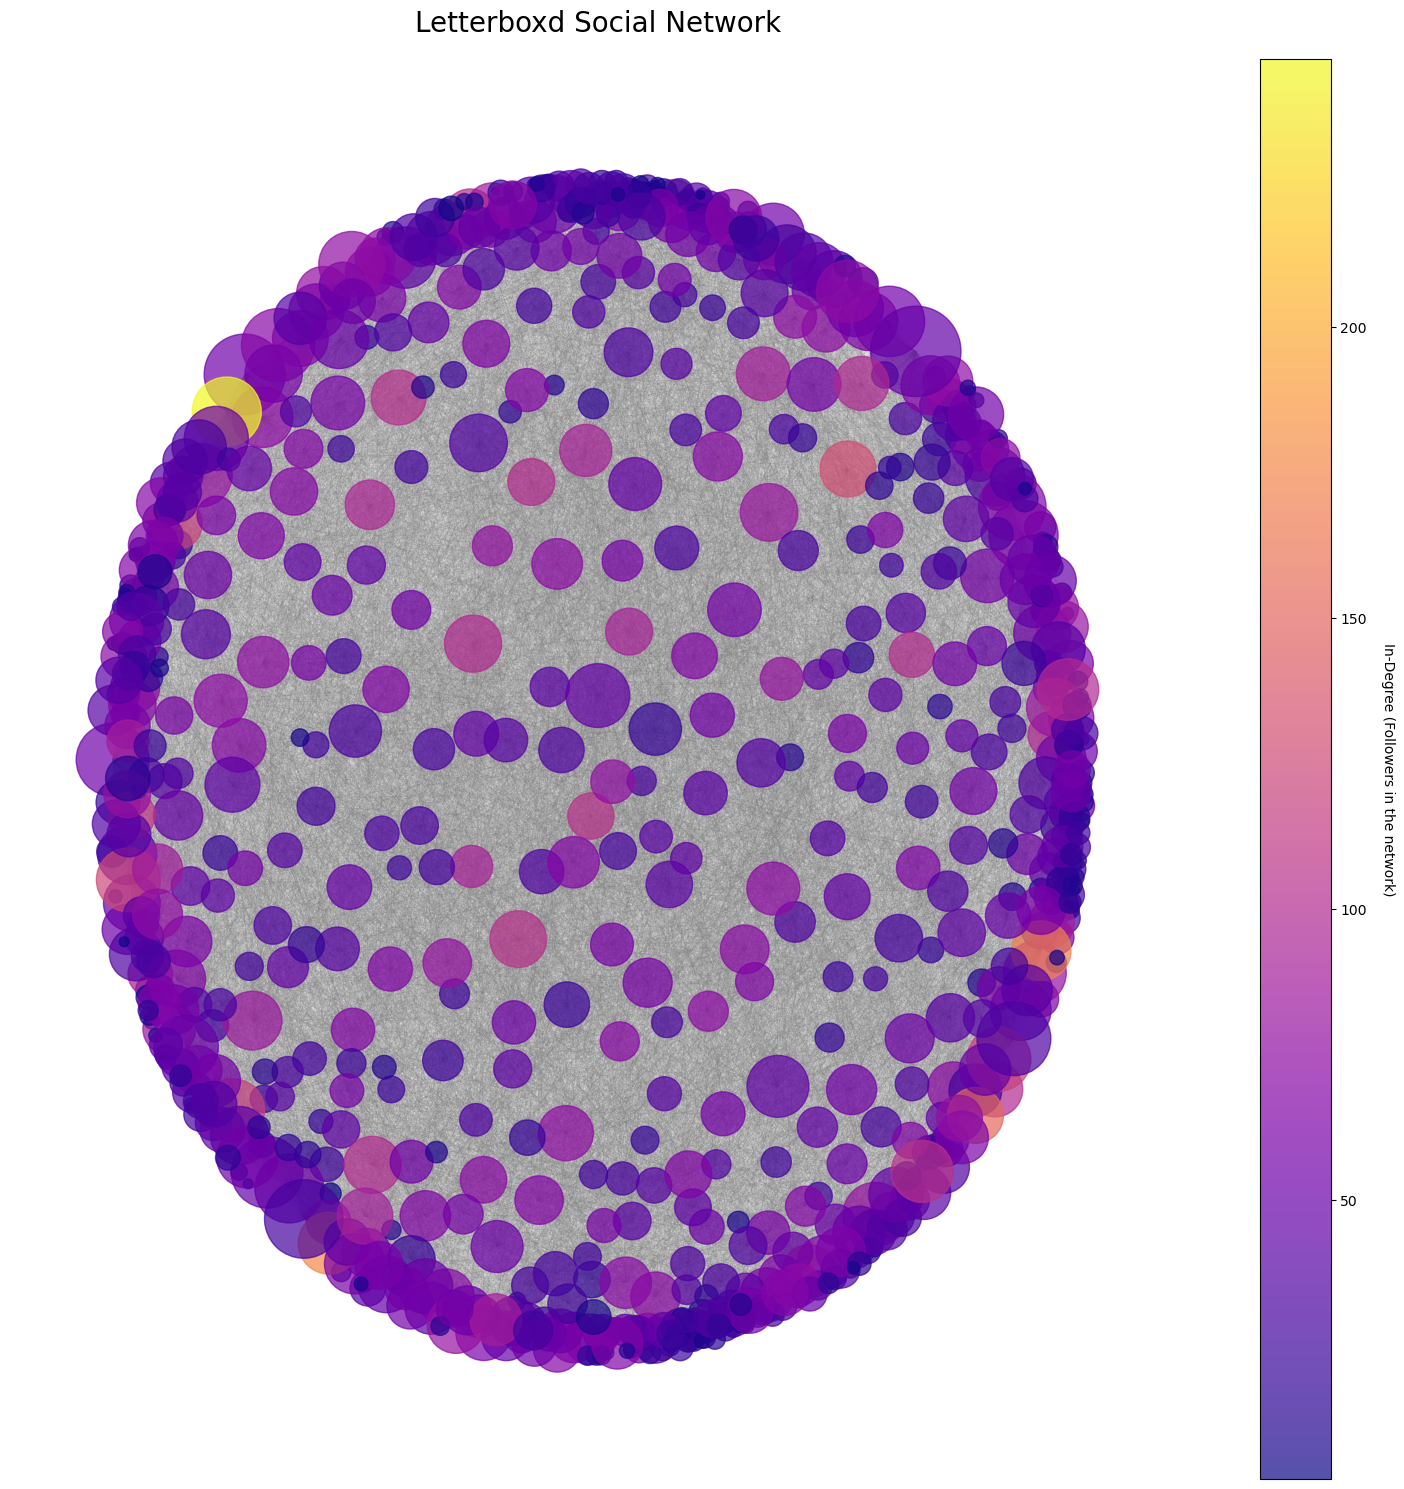

In [66]:
# Create visualization
fig, ax = plt.subplots(figsize=(15, 15))

# Node sizes based on degree
degrees = dict(G.degree())
node_sizes = [degrees[node] * 10 for node in G.nodes()]

# Node colors based on in-degree
in_degrees = dict(G.in_degree())
node_colors = [in_degrees[node] for node in G.nodes()]

# Draw edges
nx.draw_networkx_edges(
    G, positions,
    alpha=0.1,
    width=0.3,
    edge_color='gray',
    arrows=False,
    ax=ax
)

# Draw nodes
nodes = nx.draw_networkx_nodes(
    G, positions,
    node_size=node_sizes,
    node_color=node_colors,
    cmap=plt.cm.plasma,
    alpha=0.7,
    ax=ax
)

# Colorbar
cbar = plt.colorbar(nodes, ax=ax)
cbar.set_label('In-Degree (Followers in the network)', rotation=270, labelpad=20)

ax.set_title('Letterboxd Social Network', fontsize=20, pad=20)
ax.axis('off')
plt.tight_layout()
plt.show()

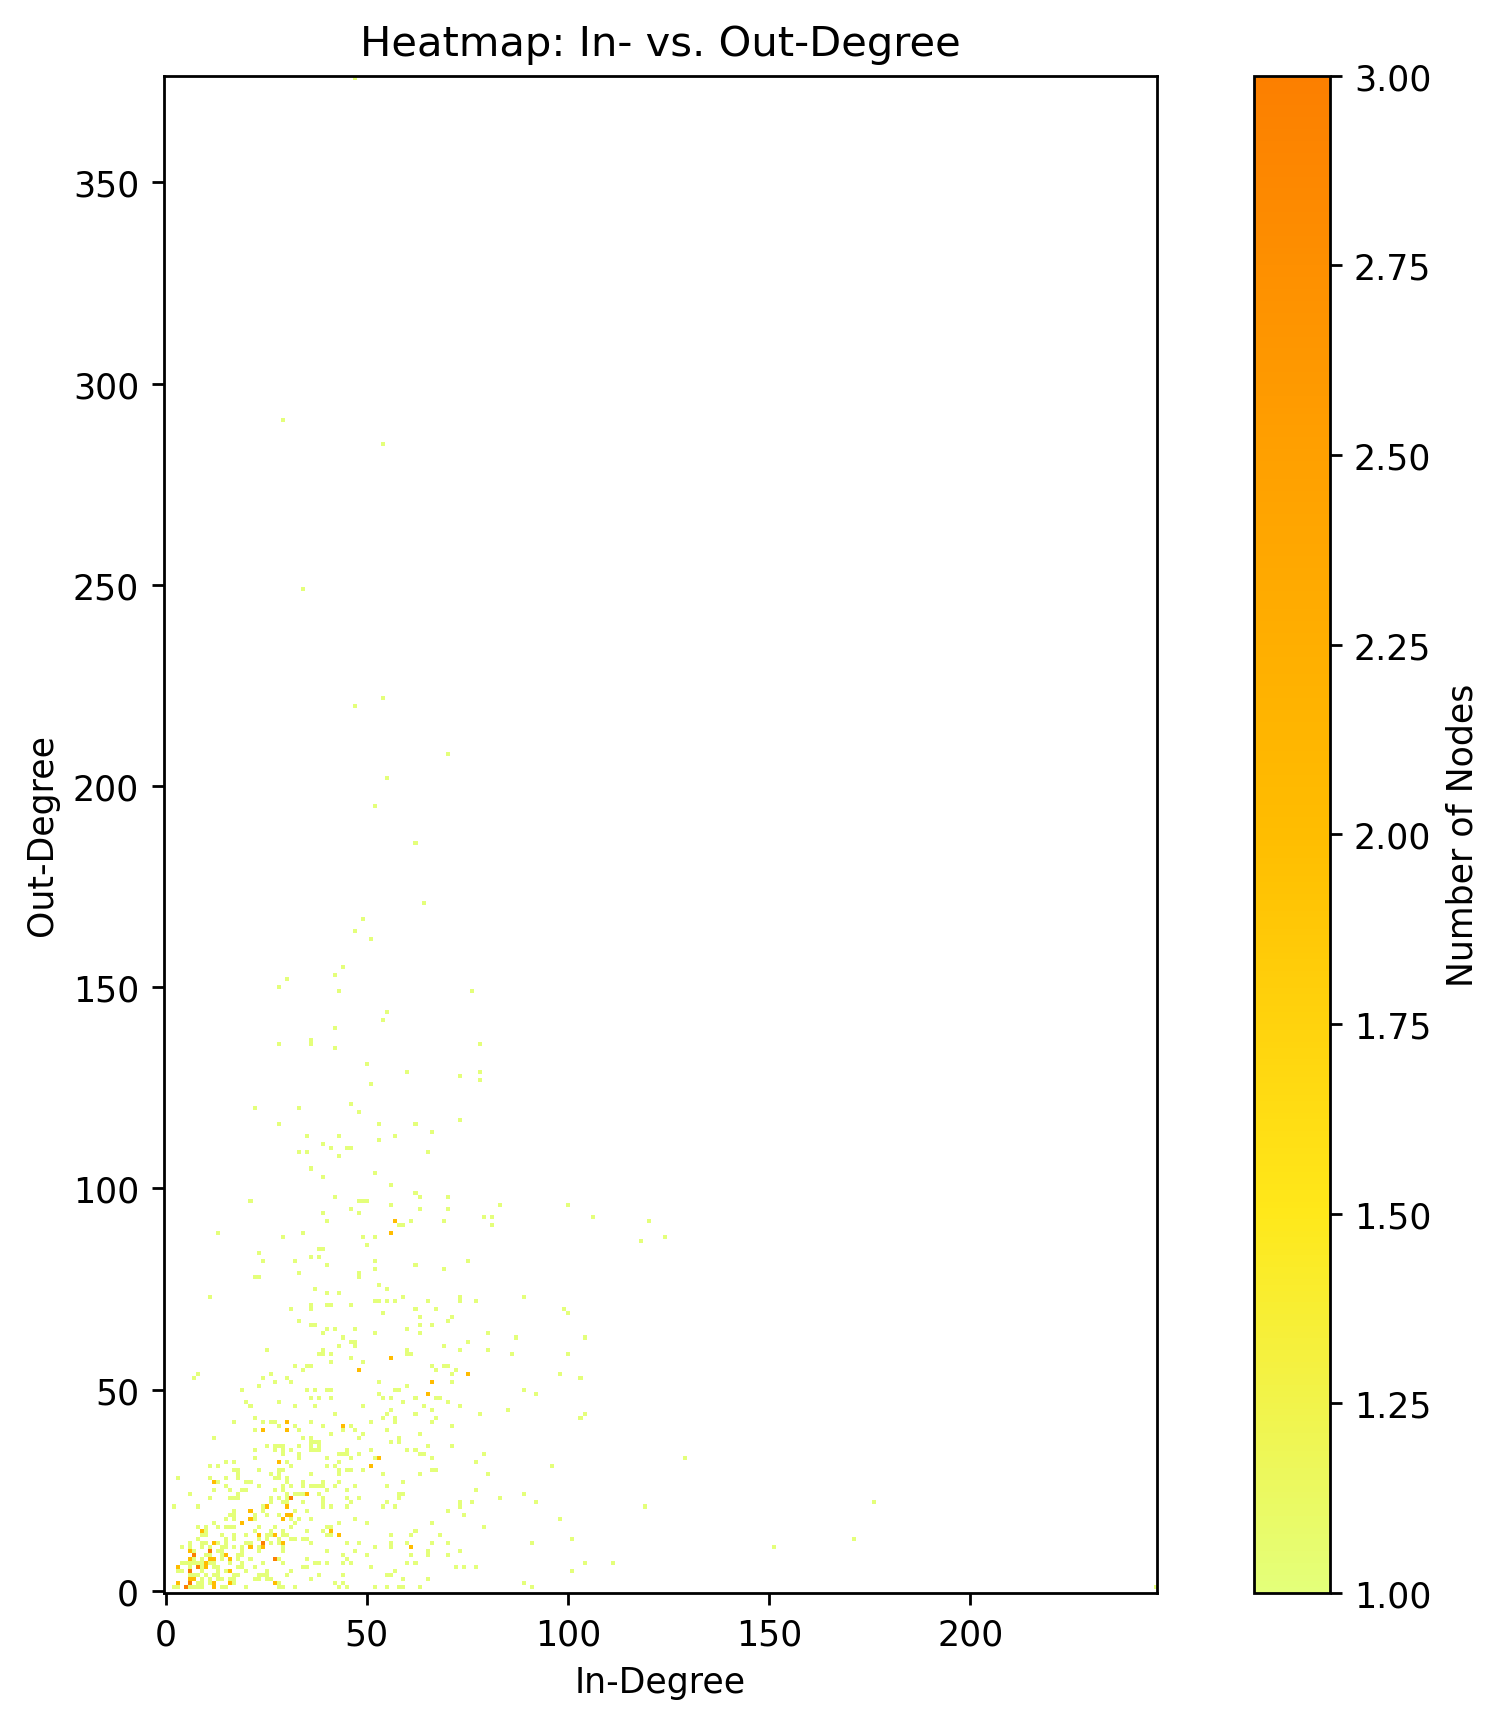

In [67]:
nodes = list(G.nodes())
in_deg  = dict(G.in_degree())
out_deg = dict(G.out_degree())

x = np.array([in_deg[n]  for n in nodes])
y = np.array([out_deg[n]  for n in nodes])

bins = (np.arange(x.max() + 2) - 0.5, np.arange(y.max() + 2) - 0.5)

heatmap, xedges, yedges = np.histogram2d(x, y, bins=bins)
extent = [xedges[0], xedges[-1], yedges[0], yedges[-1]]

plt.figure(figsize=(8, 7), dpi=250)
H = np.ma.masked_equal(heatmap.T, 0)
plt.imshow(H, extent=extent, origin='lower', cmap='Wistia')
plt.xlabel("In-Degree")
plt.ylabel("Out-Degree")
plt.title("Heatmap: In- vs. Out-Degree")
plt.colorbar(label="Number of Nodes")
plt.tight_layout()
plt.show()

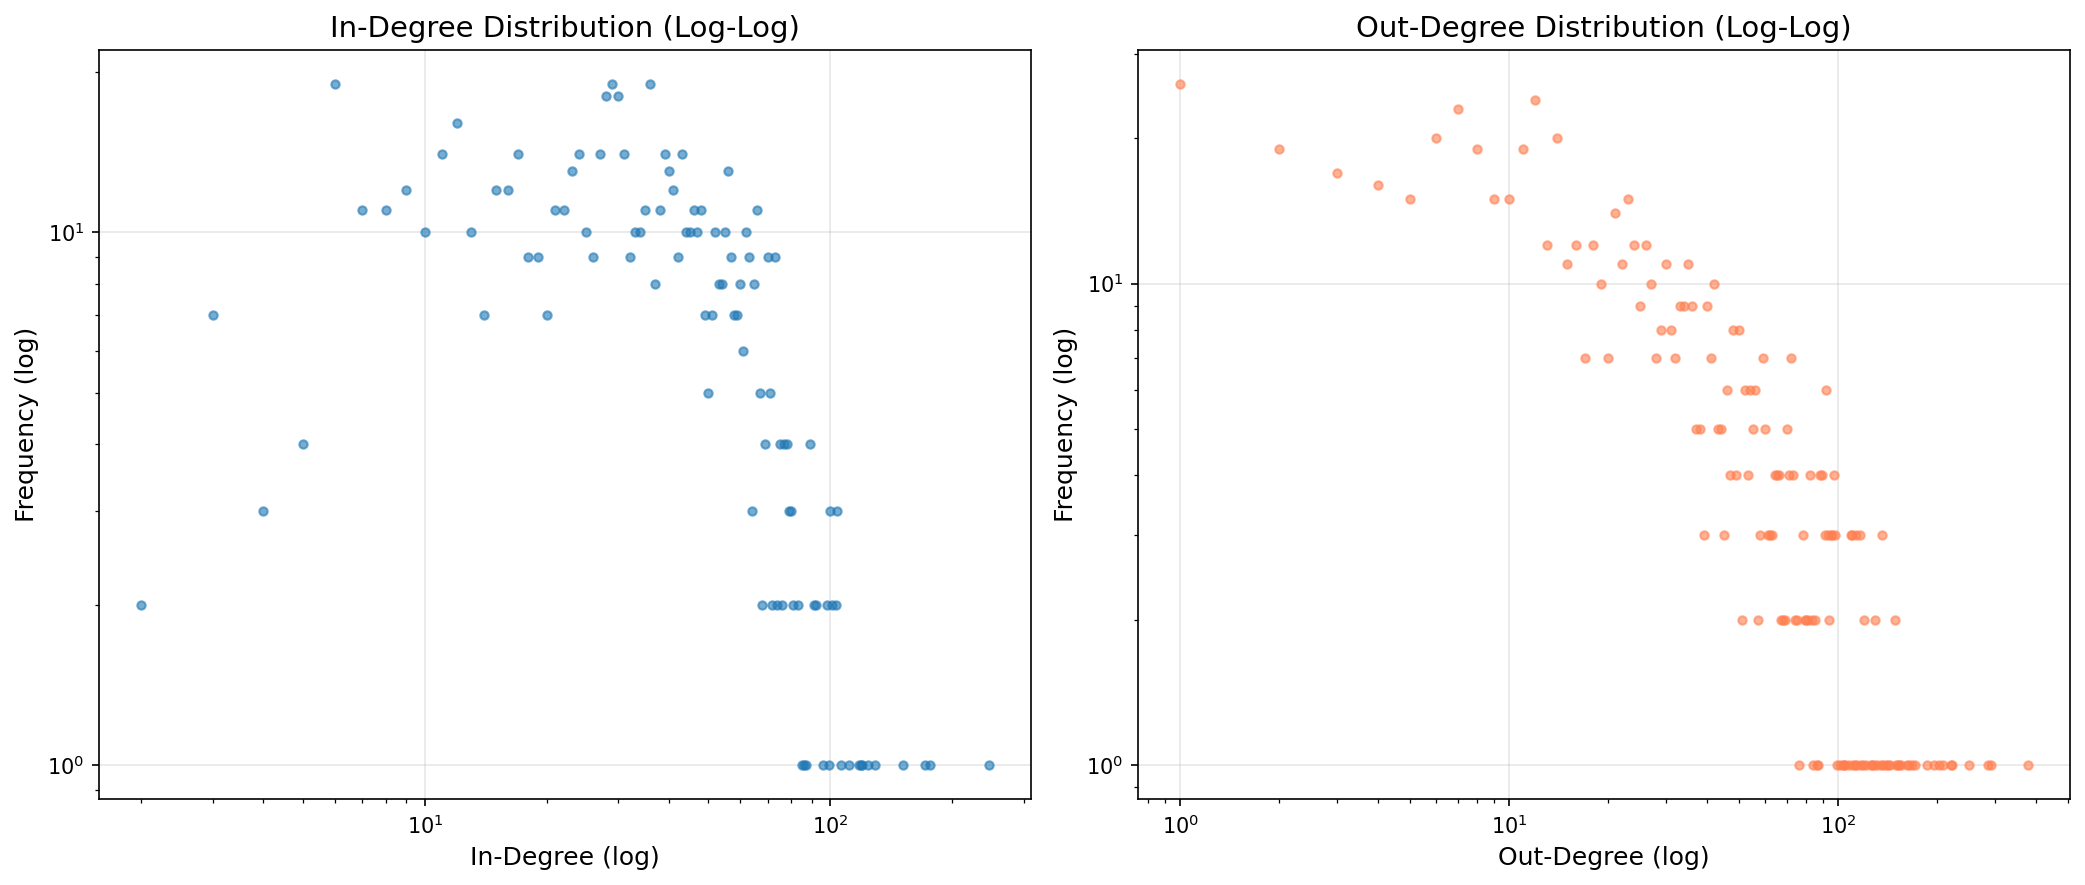

In [84]:
in_degrees = [d for n, d in G.in_degree() if d > 0]
out_degrees = [d for n, d in G.out_degree() if d > 0]

from collections import Counter
in_counts = Counter(in_degrees)
out_counts = Counter(out_degrees)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6), dpi=150)

ax1.loglog(sorted(in_counts.keys()), [in_counts[k] for k in sorted(in_counts.keys())],
           'o', alpha=0.6, markersize=4)
ax1.set_xlabel('In-Degree (log)', fontsize=12)
ax1.set_ylabel('Frequency (log)', fontsize=12)
ax1.set_title('In-Degree Distribution (Log-Log)', fontsize=14)
ax1.grid(True, alpha=0.3)

ax2.loglog(sorted(out_counts.keys()), [out_counts[k] for k in sorted(out_counts.keys())],
           'o', alpha=0.6, markersize=4, color='coral')
ax2.set_xlabel('Out-Degree (log)', fontsize=12)
ax2.set_ylabel('Frequency (log)', fontsize=12)
ax2.set_title('Out-Degree Distribution (Log-Log)', fontsize=14)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

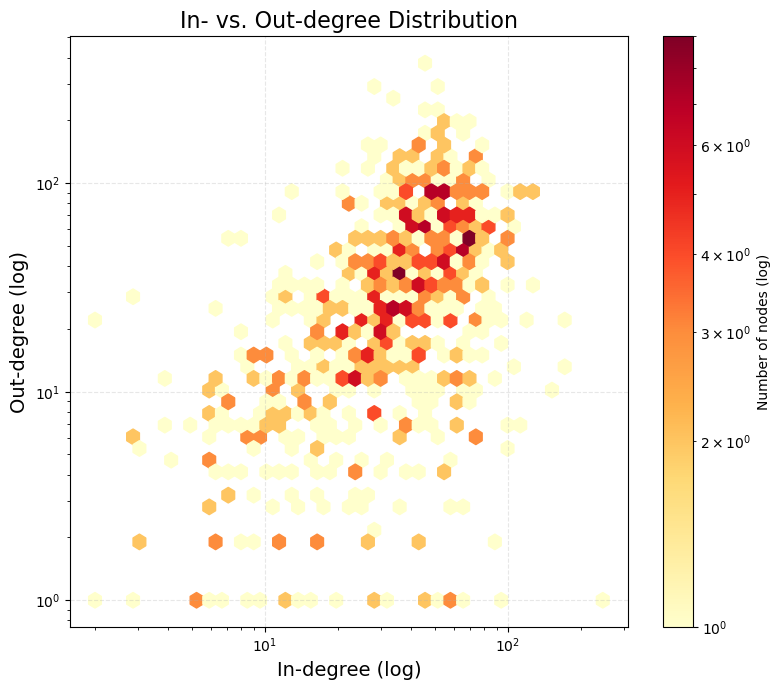

Nodes with degree > 0: 776/776
Average in-degree: 39.69
Average out-degree: 39.69
Max in-degree: 246
Max out-degree: 376


In [85]:
# Collect data (only nodes with degree > 0)
in_degrees = [G.in_degree(node) for node in G.nodes()]
out_degrees = [G.out_degree(node) for node in G.nodes()]

# Filter: only nodes with both degrees > 0
valid_pairs = [(i, o) for i, o in zip(in_degrees, out_degrees) if i > 0 and o > 0]
in_deg_filtered = [p[0] for p in valid_pairs]
out_deg_filtered = [p[1] for p in valid_pairs]

# Visualization
fig, ax = plt.subplots(figsize=(8, 7))

hb = plt.hexbin(
    in_deg_filtered,
    out_deg_filtered,
    gridsize=40,
    cmap='YlOrRd',
    mincnt=1,
    xscale='log',
    yscale='log',
    bins='log'
)

plt.xlabel('In-degree (log)', fontsize=14)
plt.ylabel('Out-degree (log)', fontsize=14)
plt.title('In- vs. Out-degree Distribution', fontsize=16)
plt.colorbar(hb, label='Number of nodes (log)')
plt.grid(True, alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()

# Statistics
print(f"Nodes with degree > 0: {len(valid_pairs)}/{len(in_degrees)}")
print(f"Average in-/out-degree: {np.mean(in_deg_filtered):.2f}")
print(f"Max in-degree: {max(in_deg_filtered)}")
print(f"Max out-degree: {max(out_deg_filtered)}")

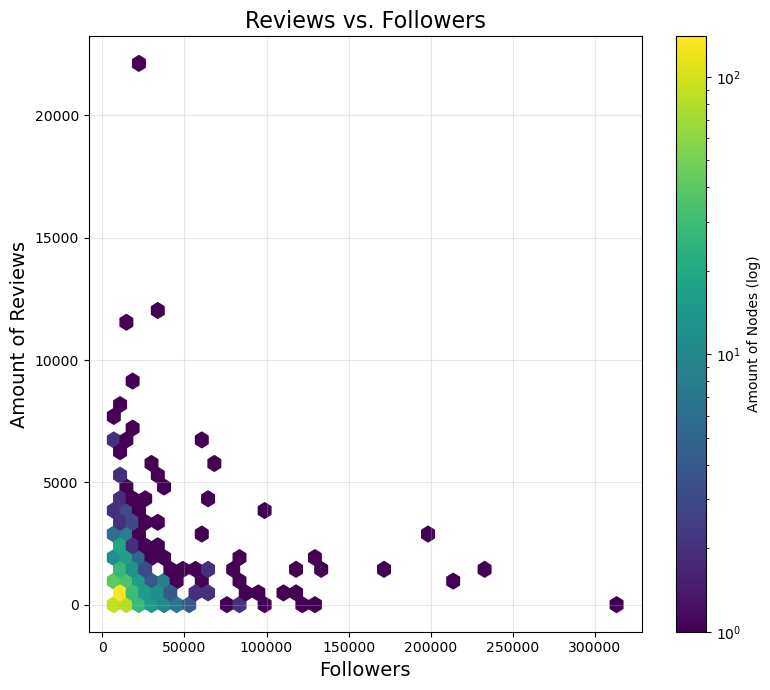

User mit Reviews: 724/776
Korrelation: 0.043


In [70]:
# Daten sammeln (nur User mit Reviews > 0)
followers = []
review_counts = []

for node in G.nodes():
  node_data = G.nodes[node]
  num_reviews = len(node_data['reviews'])

  if num_reviews > 0:  # Filter: nur User mit Reviews
      followers.append(node_data['followers_count'])
      review_counts.append(num_reviews)

# Visualisierung
fig, ax = plt.subplots(figsize=(8, 7))

plt.hexbin(followers, review_counts,
         gridsize=40,
         cmap='viridis',
         mincnt=1,
         bins='log')

plt.xlabel('Followers', fontsize=14)
plt.ylabel('Amount of Reviews', fontsize=14)
plt.title('Reviews vs. Followers', fontsize=16)
plt.colorbar(label='Amount of Nodes (log)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Korrelation
correlation = np.corrcoef(followers, review_counts)[0, 1]
print(f"User mit Reviews: {len(followers)}/{G.number_of_nodes()}")
print(f"Korrelation: {correlation:.3f}")

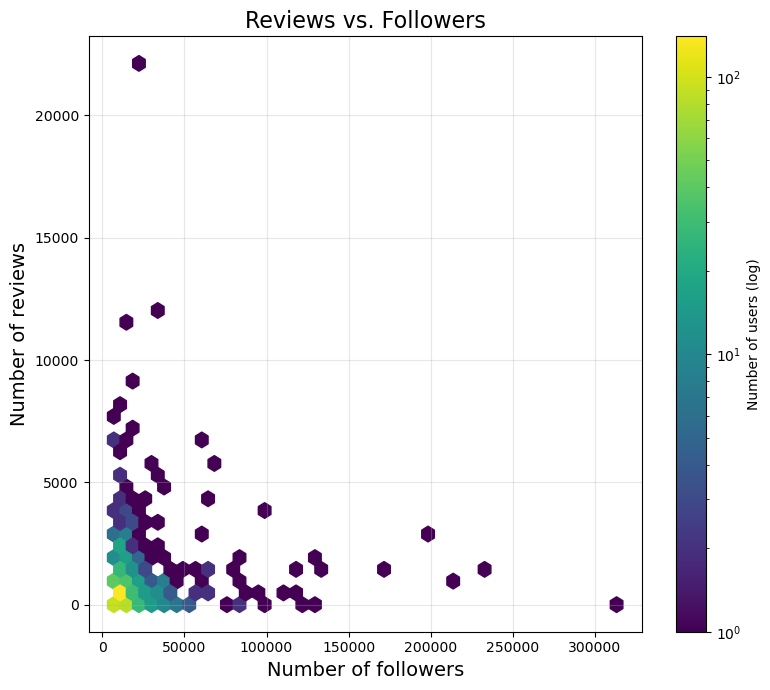

Users with reviews: 724/776
Correlation: 0.043


In [87]:
# Collect data (only users with > 0 reviews)
followers = []
review_counts = []

for node in G.nodes():
    node_data = G.nodes[node]
    num_reviews = len(node_data['reviews'])

    if num_reviews > 0:  # Filter: only users with reviews
        followers.append(node_data['followers_count'])
        review_counts.append(num_reviews)

# Visualization
fig, ax = plt.subplots(figsize=(8, 7))

plt.hexbin(
    followers,
    review_counts,
    gridsize=40,
    cmap='viridis',
    mincnt=1,
    bins='log'
)

plt.xlabel('Number of followers', fontsize=14)
plt.ylabel('Number of reviews', fontsize=14)
plt.title('Reviews vs. Followers', fontsize=16)
plt.colorbar(label='Number of users (log)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Correlation
correlation = np.corrcoef(followers, review_counts)[0, 1]
print(f"Users with reviews: {len(followers)}/{G.number_of_nodes()}")
print(f"Correlation: {correlation:.3f}")

In [72]:
total_degrees = in_degrees + out_degrees
total_degrees.sort()
in_deg_pos  = [d for d in in_degrees  if d > 0]
out_deg_pos = [d for d in out_degrees if d > 0]
tot_deg_pos = [d for d in total_degrees if d > 0]
print("Degree Exponent:\n")
print(f"In-Degree:\t{powerlaw.Fit(in_deg_pos).alpha}")
print(f"Out-Degree:\t{powerlaw.Fit(out_deg_pos).alpha}")
print(f"Total-Degree:\t{powerlaw.Fit(tot_deg_pos).alpha}")

Degree Exponent:

In-Degree:	5.430939864943631
Out-Degree:	4.504399190499479
Total-Degree:	4.4878575763294535


Calculating best minimal value for power law fit
/Users/boldizsarhorvath/miniconda3/envs/SocialGraphs/lib/python3.12/site-packages/powerlaw.py:699: RuntimeWarning: invalid value encountered in divide
  (CDF_diff**2) /
Calculating best minimal value for power law fit
Calculating best minimal value for power law fit


Followers - Min: 6918, Max: 449436, Unique: 754
In-Degrees - Min: 2, Max: 246, Unique: 105
Total nodes: 776

After filtering zeros: 776 nodes


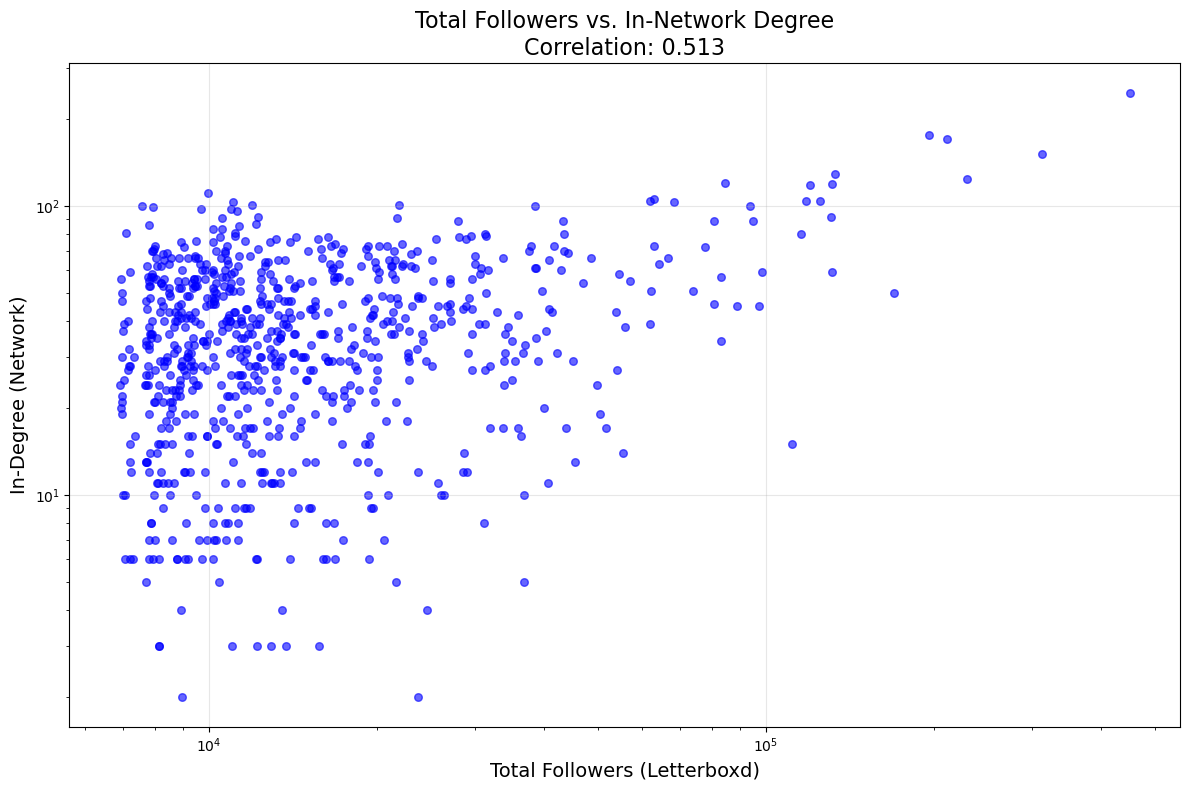


Correlation: 0.5127


In [88]:
# Debug and plot correlation
import numpy as np
import matplotlib.pyplot as plt

# Collect data
followers = [G.nodes[node]['followers_count'] for node in G.nodes()]
in_degrees = [G.in_degree(node) for node in G.nodes()]

# Check data
print(f"Followers - Min: {min(followers)}, Max: {max(followers)}, Unique: {len(set(followers))}")
print(f"In-Degrees - Min: {min(in_degrees)}, Max: {max(in_degrees)}, Unique: {len(set(in_degrees))}")
print(f"Total nodes: {len(followers)}")

# Filter out zeros for log scale
valid_pairs = [(f, d) for f, d in zip(followers, in_degrees) if f > 0 and d > 0]
followers_filtered = [p[0] for p in valid_pairs]
in_deg_filtered = [p[1] for p in valid_pairs]

print(f"\nAfter filtering zeros: {len(valid_pairs)} nodes")

# Calculate correlation
correlation = np.corrcoef(followers_filtered, in_deg_filtered)[0, 1]

# Plot with scatter (easier to see what's happening)
fig, ax = plt.subplots(figsize=(12, 8))

plt.scatter(followers_filtered, in_deg_filtered, alpha=0.6, s=30, c='blue')

plt.xlabel('Total Followers (Letterboxd)', fontsize=14)
plt.ylabel('In-Degree (Network)', fontsize=14)
plt.title(f'Total Followers vs. In-Network Degree\nCorrelation: {correlation:.3f}', fontsize=16)

plt.xscale('log')
plt.yscale('log')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nCorrelation: {correlation:.4f}")

In [74]:
# Convert directed graph to undirected
GUndirected = G.to_undirected()

print(f"Original directed graph: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges")
print(f"Undirected graph: {GUndirected.number_of_nodes()} nodes, {GUndirected.number_of_edges()} edges\n")

# Run Louvain community detection
print("Running Louvain algorithm...\n")
communities = nx.community.louvain_communities(GUndirected, seed=42, resolution=2)

# Statistics
print(f"Number of communities detected: {len(communities)}")
print(f"\nCommunity sizes (sorted by size):")
sorted_communities = sorted(communities, key=len, reverse=True)
for i, comm in enumerate(sorted_communities, 1):
  print(f"  Community {i}: {len(comm)} nodes ({len(comm)/G.number_of_nodes()*100:.1f}%)")

# Create node-to-community mapping
node_to_community = {}
for i, comm in enumerate(communities):
  for node in comm:
      node_to_community[node] = i

# Modularity score
modularity = nx.community.modularity(GUndirected, communities)
print(f"\nModularity: {modularity:.4f}")

# Top 5 communities by total follower influence
print("\nTop 5 communities by total follower influence:")
comm_stats = []
for i, comm in enumerate(sorted_communities):
  total_followers = sum(G.nodes[node]['followers_count'] for node in comm)
  avg_followers = total_followers / len(comm)
  comm_stats.append((i+1, len(comm), total_followers, avg_followers))

for rank, (comm_id, size, total, avg) in enumerate(sorted(comm_stats, key=lambda x: x[2], reverse=True)[:5], 1):
  print(f"  {rank}. Community {comm_id}: {size} nodes, {total:,} total followers (avg: {avg:,.0f})")

Original directed graph: 776 nodes, 30800 edges
Undirected graph: 776 nodes, 25999 edges

Running Louvain algorithm...

Number of communities detected: 22

Community sizes (sorted by size):
  Community 1: 143 nodes (18.4%)
  Community 2: 112 nodes (14.4%)
  Community 3: 75 nodes (9.7%)
  Community 4: 70 nodes (9.0%)
  Community 5: 57 nodes (7.3%)
  Community 6: 43 nodes (5.5%)
  Community 7: 38 nodes (4.9%)
  Community 8: 36 nodes (4.6%)
  Community 9: 31 nodes (4.0%)
  Community 10: 27 nodes (3.5%)
  Community 11: 26 nodes (3.4%)
  Community 12: 23 nodes (3.0%)
  Community 13: 17 nodes (2.2%)
  Community 14: 16 nodes (2.1%)
  Community 15: 16 nodes (2.1%)
  Community 16: 13 nodes (1.7%)
  Community 17: 9 nodes (1.2%)
  Community 18: 7 nodes (0.9%)
  Community 19: 6 nodes (0.8%)
  Community 20: 5 nodes (0.6%)
  Community 21: 5 nodes (0.6%)
  Community 22: 1 nodes (0.1%)

Modularity: 0.2267

Top 5 communities by total follower influence:
  1. Community 1: 143 nodes, 3,620,637 total foll

Total reviews: 699160
Unique movies: 84201

Top 2000 movies sorted by number of reviews:
   1. Scream                                        -  883 reviews
   2. Dune                                          -  797 reviews
   3. La La Land                                    -  787 reviews
   4. Halloween                                     -  777 reviews
   5. Oppenheimer                                   -  636 reviews
   6. Parasite                                      -  630 reviews
   7. Nosferatu                                     -  628 reviews
   8. Superman                                      -  608 reviews
   9. Barbie                                        -  602 reviews
  10. Anora                                         -  601 reviews
  11. Challengers                                   -  598 reviews
  12. Dune: Part Two                                -  594 reviews
  13. The Substance                                 -  575 reviews
  14. Little Women                      

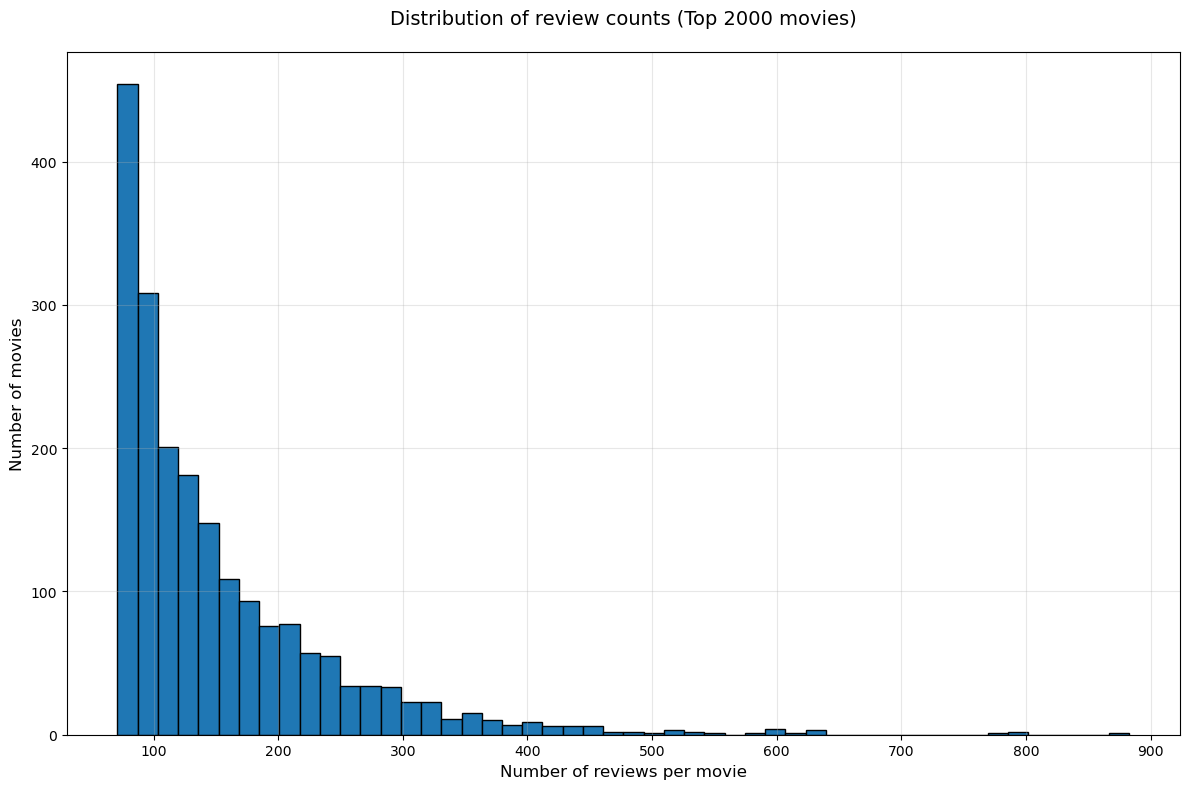


Statistics (Top 2000 movies):
Mean: 152.58 reviews per movie
Median: 123 reviews per movie
Maximum: 883 reviews
Minimum: 71 reviews


In [89]:
# Read reviews CSV and sort by most frequent movies
df = pd.read_csv('./../Data/CSV/reviews.csv')

print(f"Total reviews: {len(df)}")
print(f"Unique movies: {df['moviename'].nunique()}\n")

# Group by movie name and count
movie_counts = df['moviename'].value_counts()

# Top 2000 movies
top_2000 = movie_counts.head(2000)

# Print top 2000 movies with their review counts
print("Top 2000 movies sorted by number of reviews:")
print("=" * 60)
for i, (movie, count) in enumerate(top_2000.items(), 1):
    print(f"{i:4d}. {movie:45s} - {count:4d} reviews")

# Visualization: distribution of review counts (Top 2000)
fig, ax = plt.subplots(figsize=(12, 8))
ax.hist(top_2000.values, bins=50, edgecolor='black')
ax.set_xlabel('Number of reviews per movie', fontsize=12)
ax.set_ylabel('Number of movies', fontsize=12)
ax.set_title('Distribution of review counts (Top 2000 movies)', fontsize=14, pad=20)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Statistics (Top 2000)
print(f"\nStatistics (Top 2000 movies):")
print(f"Mean: {top_2000.mean():.2f} reviews per movie")
print(f"Median: {top_2000.median():.0f} reviews per movie")
print(f"Maximum: {top_2000.max()} reviews")
print(f"Minimum: {top_2000.min()} reviews")

In [90]:
print(f"Total reviews before: {len(df)}")
print(f"Unique movies before: {df['moviename'].nunique()}\n")

# Group by movie name and count
movie_counts = df['moviename'].value_counts()

# Identify top 500 movies by number of reviews
top_500_movies = movie_counts.head(500).index.tolist()

# Keep only reviews of the top 500 movies
df_trimmed = df[df['moviename'].isin(top_500_movies)]

print(f"Total reviews after: {len(df_trimmed)} ({len(df_trimmed)/len(df)*100:.1f}%)")
print(f"Unique movies after: {df_trimmed['moviename'].nunique()}")
print(f"Removed reviews: {len(df) - len(df_trimmed)}")

# Save as new CSV
df_trimmed.to_csv('reviews_top500.csv', index=False)
print("\nSaved as 'reviews_top500.csv'")

Total reviews before: 699160
Unique movies before: 84201

Total reviews after: 138911 (19.9%)
Unique movies after: 500
Removed reviews: 560249

Saved as 'reviews_top500.csv'


In [91]:
print(f"Total reviews before: {len(df)}")
print(f"Unique movies before: {df['moviename'].nunique()}")
print(f"Unique users before: {df['username_of_creator'].nunique()}\n")

# Group by movie name and count
movie_counts = df['moviename'].value_counts()

# Identify top 500 movies
top_500_movies = movie_counts.head(500).index.tolist()

# Keep only reviews of the top 500 movies
df_trimmed = df[df['moviename'].isin(top_500_movies)]

print(f"Total reviews after: {len(df_trimmed)} ({len(df_trimmed)/len(df)*100:.1f}%)")
print(f"Unique movies after: {df_trimmed['moviename'].nunique()}")
print(f"Unique users after: {df_trimmed['username_of_creator'].nunique()}")
print(f"Removed reviews: {len(df) - len(df_trimmed)}")
print(
    "Users who no longer have any reviews: "
    f"{df['username_of_creator'].nunique() - df_trimmed['username_of_creator'].nunique()}"
)

# Save as new CSV
df_trimmed.to_csv('reviews_top500.csv', index=False)
print("\nSaved as 'reviews_top500.csv'")

Total reviews before: 699160
Unique movies before: 84201
Unique users before: 758

Total reviews after: 138911 (19.9%)
Unique movies after: 500
Unique users after: 743
Removed reviews: 560249
Users who no longer have any reviews: 15

Saved as 'reviews_top500.csv'


Total Reviews: 699160
Unique Users: 758



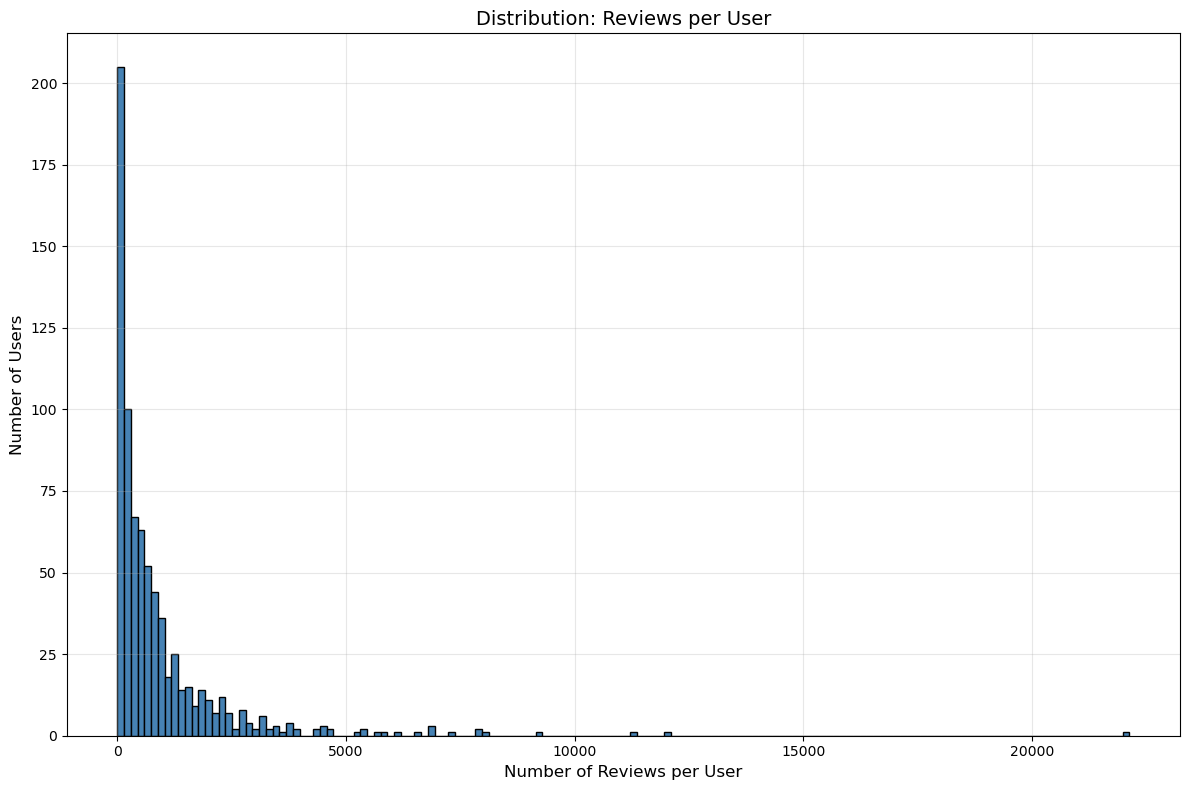


Statistics:
Average: 922.37 reviews per user
Median: 460 reviews per user
Maximum: 22130 reviews (User: punq)
Minimum: 1 reviews

Users with only 1 review: 6 (0.8%)


In [92]:
print(f"Total Reviews: {len(df)}")
print(f"Unique Users: {df['username_of_creator'].nunique()}\n")

# Group by user and count
user_review_counts = df['username_of_creator'].value_counts()

# Visualization: Distribution of review counts per user (finer bins)
fig, ax = plt.subplots(figsize=(12, 8))

ax.hist(user_review_counts.values, bins=150, color='steelblue', edgecolor='black')
ax.set_xlabel('Number of Reviews per User', fontsize=12)
ax.set_ylabel('Number of Users', fontsize=12)
ax.set_title('Distribution: Reviews per User', fontsize=14)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Statistics
print(f"\nStatistics:")
print(f"Average: {user_review_counts.mean():.2f} reviews per user")
print(f"Median: {user_review_counts.median():.0f} reviews per user")
print(f"Maximum: {user_review_counts.max()} reviews (User: {user_review_counts.idxmax()})")
print(f"Minimum: {user_review_counts.min()} reviews")
print(f"\nUsers with only 1 review: {(user_review_counts == 1).sum()} ({(user_review_counts ==
1).sum()/len(user_review_counts)*100:.1f}%)")

In [79]:
pairs_sorted = sorted(G.in_degree(), key=lambda t: t[1], reverse=True)
highest_in_node, in_degree = pairs_sorted[0]
print(f"Node with the highest in-degree: {highest_in_node}\n")

neighbors_to_highest_in = list(G.predecessors(highest_in_node))
print(f"There are {len(neighbors_to_highest_in)} nodes pointing towards {highest_in_node}, for example:\n\n{neighbors_to_highest_in[:5]}\n")

print(f"These are the top 5 nodes with the highest in-degree:\n\n{pairs_sorted[:5]}")

Node with the highest in-degree: mscorsese

There are 246 nodes pointing towards mscorsese, for example:

['812filmreviews', 'aadowd', 'aegxpredator', 'afi', 'aksually']

These are the top 5 nodes with the highest in-degree:

[('mscorsese', 246), ('davidehrlich', 176), ('lilfilm', 171), ('itscharlibb', 151), ('demiadejuyigbe', 129)]


In [80]:
pairs_sorted_out = sorted(G.out_degree(), key=lambda t: t[1], reverse=True)
highest_out_node, out_degree = pairs_sorted_out[0]
print(f"Node with the highest out-degree: {highest_out_node}\n")

neighbors_to_highest_out = list(G.successors(highest_out_node))
print(f"There are {len(neighbors_to_highest_out)} nodes are being pointed at by {highest_out_node}, for example:\n\n{neighbors_to_highest_out[:5]}\n")

print(f"These are the top 5 nodes with the highest out-degree:\n\n{pairs_sorted_out[:5]}")

Node with the highest out-degree: snakes69

There are 376 nodes are being pointed at by snakes69, for example:

['ffrenchnewwave', 'dayaphoria', 'bransonreese', 'bjstreu513', 'labuzamovies']

These are the top 5 nodes with the highest out-degree:

[('snakes69', 376), ('magrosleau', 291), ('brandonlugo', 285), ('tediously_brief', 249), ('ehamstra8938', 222)]


In [81]:
# === RECIPROCITY ANALYSIS ===
print("=== RECIPROCITY ANALYSIS ===\n")

# Overall reciprocity
reciprocity = nx.reciprocity(G)
print(f"Overall Reciprocity: {reciprocity:.4f} ({reciprocity*100:.1f}%)\n")

# Count mutual vs one-way edges
mutual_edges = 0
for u, v in G.edges():
  if G.has_edge(v, u):
      mutual_edges += 1

# Note: Each mutual edge is counted twice (A->B and B->A)
mutual_edges = mutual_edges // 2
one_way_edges = G.number_of_edges() - (mutual_edges * 2)

print(f"Total directed edges: {G.number_of_edges():,}")
print(f"Mutual relationships: {mutual_edges:,} (counted as {mutual_edges*2:,} directed edges)")
print(f"One-way follows: {one_way_edges:,}\n")

print("Interpretation:")
print(f"  → {reciprocity*100:.1f}% of all follows are reciprocated")
if reciprocity > 0.5:
  print(f"  → HIGH reciprocity: Network behaves like FRIENDSHIPS")
  print(f"  → Users tend to follow each other back")
elif reciprocity > 0.2:
  print(f"  → MEDIUM reciprocity: Mix of friendships and followers")
else:
  print(f"  → LOW reciprocity: Network behaves like TWITTER/INSTAGRAM")
  print(f"  → Strong influencer/follower dynamics")

=== RECIPROCITY ANALYSIS ===

Overall Reciprocity: 0.3118 (31.2%)

Total directed edges: 30,800
Mutual relationships: 4,801 (counted as 9,602 directed edges)
One-way follows: 21,198

Interpretation:
  → 31.2% of all follows are reciprocated
  → MEDIUM reciprocity: Mix of friendships and followers


In [82]:
# === CONNECTIVITY ANALYSIS ===
print("\n=== CONNECTIVITY ANALYSIS ===\n")

# Strongly connected components (directed)
scc = list(nx.strongly_connected_components(G))
scc_sizes = sorted([len(c) for c in scc], reverse=True)

print(f"Strongly Connected Components (SCC): {len(scc)}")
print(f"  Largest SCC: {scc_sizes[0]} nodes ({scc_sizes[0]/G.number_of_nodes()*100:.1f}%)")
if len(scc_sizes) > 1:
  print(f"  2nd largest: {scc_sizes[1]} nodes")
  print(f"  3rd largest: {scc_sizes[2]} nodes" if len(scc_sizes) > 2 else "")

# Weakly connected components
wcc = list(nx.weakly_connected_components(G))
wcc_sizes = sorted([len(c) for c in wcc], reverse=True)

print(f"\nWeakly Connected Components (WCC): {len(wcc)}")
print(f"  Largest WCC: {wcc_sizes[0]} nodes ({wcc_sizes[0]/G.number_of_nodes()*100:.1f}%)")

# Path length analysis (on largest WCC)
largest_wcc_nodes = max(wcc, key=len)
largest_wcc_subgraph = G.subgraph(largest_wcc_nodes)

print(f"\n--- Path Length Analysis (Largest WCC) ---")
try:
  # Use undirected version for diameter
  G_undirected = largest_wcc_subgraph.to_undirected()

  # Average shortest path (undirected)
  avg_path = nx.average_shortest_path_length(G_undirected)
  diameter = nx.diameter(G_undirected)

  print(f"Average Shortest Path Length: {avg_path:.2f} steps")
  print(f"Network Diameter: {diameter} steps")

  print("\nInterpretation:")
  if avg_path < 3:
      print(f"  → VERY SMALL WORLD: Average {avg_path:.1f} degrees of separation")
  elif avg_path < 4:
      print(f"  → SMALL WORLD: Average {avg_path:.1f} degrees of separation")
  else:
      print(f"  → LARGE NETWORK: Average {avg_path:.1f} degrees of separation")

  print(f"  → Maximum distance: {diameter} steps (diameter)")

except:
  print("  (Could not calculate - network might be disconnected)")

print("\n--- SCC Interpretation ---")
if scc_sizes[0] / G.number_of_nodes() > 0.8:
  print(f"  → Network has a GIANT SCC ({scc_sizes[0]/G.number_of_nodes()*100:.1f}%)")
  print(f"  → Most users can reach each other via follows")
else:
  print(f"  → Network is FRAGMENTED (largest SCC only {scc_sizes[0]/G.number_of_nodes()*100:.1f}%)")
  print(f"  → Many isolated groups or one-way follow chains")


=== CONNECTIVITY ANALYSIS ===

Strongly Connected Components (SCC): 4
  Largest SCC: 771 nodes (99.4%)
  2nd largest: 2 nodes
  3rd largest: 2 nodes

Weakly Connected Components (WCC): 1
  Largest WCC: 776 nodes (100.0%)

--- Path Length Analysis (Largest WCC) ---
Average Shortest Path Length: 2.05 steps
Network Diameter: 4 steps

Interpretation:
  → VERY SMALL WORLD: Average 2.0 degrees of separation
  → Maximum distance: 4 steps (diameter)

--- SCC Interpretation ---
  → Network has a GIANT SCC (99.4%)
  → Most users can reach each other via follows
